# Làm việc với File Objects - Đọc và Ghi File

Trong bài giảng này, chúng ta sẽ tìm hiểu cách làm việc với **file objects** trong Python và một số kỹ thuật hữu ích để tương tác với file. Dù bạn sử dụng Python để phát triển ứng dụng desktop hay ứng dụng web, việc xử lý file là một kỹ năng quan trọng. Chúng ta sẽ đi qua các cách mở, đọc, ghi và sao chép file, sử dụng các phương pháp hiệu quả như **context manager** và xử lý file lớn.


## 1. Mở File trong Python

Để làm việc với file, chúng ta sử dụng hàm **open()** tích hợp sẵn trong Python để tạo một **file object**. Hàm này yêu cầu ít nhất một tham số là tên file (hoặc đường dẫn đến file). Nếu file nằm trong cùng thư mục với mã Python, bạn chỉ cần cung cấp tên file. Nếu file nằm ở thư mục khác, bạn cần cung cấp đường dẫn đầy đủ.

Hàm **open()** cũng cho phép chỉ định **chế độ mở file**:
- **'r'**: Mở file để đọc (mặc định).
- **'w'**: Mở file để ghi (nếu file đã tồn tại, nó sẽ bị ghi đè).
- **'a'**: Mở file để thêm nội dung (append).
- **'r+'**: Mở file để vừa đọc vừa ghi.

Ví dụ, giả sử chúng ta có file `test.txt` trong cùng thư mục với nội dung:

```
This is line 1
This is line 2
This is line 3
```

### Cách mở file không dùng context manager (không khuyến khích)

Chúng ta có thể mở file bằng cách gán hàm `open()` vào một biến và sau đó đóng file bằng phương thức `.close()`:

In [ ]:
# Mở file để đọc
f = open('test.txt', 'r') # nội dung cần truy xuất, cần làm việc trên file này.
print(f.name)  # In tên file: test.txt
print(f.mode)  # In chế độ: r
f.close()      # Đóng file # (vì sao phải đóng? Để giải phóng tài nguyên hệ thống và tránh rò rỉ bộ nhớ.

test.txt
r


**Kết quả**:
```
test.txt
r
```

**Lưu ý**: Khi mở file theo cách này, bạn phải nhớ gọi `.close()` để đóng file. Nếu không, có thể gây ra **memory leak** hoặc vượt quá giới hạn số lượng file mở trên hệ thống, dẫn đến lỗi.

---

## 2. Sử dụng Context Manager (Khuyến khích)

Để tránh việc quên đóng file, cách tốt nhất là sử dụng **context manager** với từ khóa `with`. Context manager tự động đóng file sau khi hoàn thành công việc, ngay cả khi có lỗi xảy ra.

Cú pháp cơ bản:

In [ ]:
with open('test.txt', 'r') as f:
    # Làm việc với file ở đây
    pass
# Khi thoát khỏi khối with, file sẽ tự động được đóng lại.

**Lợi ích**:
- File sẽ tự động được đóng sau khi thoát khỏi khối `with`.
- Xử lý lỗi an toàn hơn.
- Code dễ đọc và gọn gàng hơn.

Ví dụ:

In [3]:
with open('test.txt', 'r') as f:
    print(f.name)  # In tên file
    print(f.mode)  # In chế độ
    print(f.closed)  # Kiểm tra trạng thái file trong khối (False)

print(f.closed)  # Kiểm tra trạng thái file ngoài khối (True)

test.txt
r
False
True


**Kết quả**:
```
test.txt
r
False
True
```

**Giải thích**: Sau khi thoát khỏi khối `with`, file tự động được đóng (`f.closed` trả về `True`). Nếu bạn cố đọc file sau khi thoát khối, Python sẽ báo lỗi:

In [6]:
with open('test.txt', 'r') as f:
    pass # File tự động đóng ở đây 

print(f.read())  # Lỗi: ValueError: I/O operation on closed file

ValueError: I/O operation on closed file.

---

## 3. Đọc Nội dung File

Có nhiều cách để đọc nội dung từ file trong Python. Chúng ta sẽ khám phá các phương thức phổ biến:

### 3.1. Đọc toàn bộ file với `.read()`

Phương thức `.read()` đọc toàn bộ nội dung file và trả về dưới dạng một chuỗi.

In [7]:
with open('test.txt', 'r') as f:
    f_contents = f.read() # Đọc toàn bộ nội dung file vào biến f_contents
    print("Kết quả output:\n",f_contents)

Kết quả output:
 Hàm **open()** cũng cho phép chỉ định **chế độ mở file**:
- **'r'**: Mở file để đọc (mặc định).
- **'w'**: Mở file để ghi (nếu file đã tồn tại, nó sẽ bị ghi đè).
- **'a'**: Mở file để thêm nội dung (append).
- **'r+'**: Mở file để vừa đọc vừa ghi.

Ví dụ, giả sử chúng ta có file `test.txt` trong cùng thư mục với nội dung:


In [10]:
with open('students.txt', 'r') as f:
    f_contents = f.read()
    print("Kết quả output:\n",f_contents)
    print("Số ký tự trong file:", len(f_contents))  # Đếm số ký tự trong file
    

Kết quả output:
     {"name": "Nguyễn Văn An", "gender": "Nam", "avg": 9.2},
    {"name": "Trần Thị Bình", "gender": "Nữ",  "avg": 8.5},
    {"name": "Lê Văn Cường", "gender": "Nam", "avg": 7.8},
    {"name": "Phạm Thị Dung", "gender": "Nữ",  "avg": 6.9},
    {"name": "Hoàng Văn Em", "gender": "Nam", "avg": 5.4},
Số ký tự trong file: 297


**Kết quả**:
```
This is line 1
This is line 2
This is line 3
```

**Lưu ý**: Phương thức này phù hợp với file nhỏ. Với file lớn, việc đọc toàn bộ nội dung có thể gây tốn bộ nhớ.

### 3.2. Đọc từng dòng với `.readlines()`

Phương thức `.readlines()` đọc tất cả các dòng và trả về một **danh sách** các chuỗi, mỗi chuỗi là một dòng trong file.

In [1]:
with open('test.txt', 'r') as f:
    f_contents = f.readlines()
    print(f_contents)

['Hàm **open()** cũng cho phép chỉ định **chế độ mở file**:\n', "- **'r'**: Mở file để đọc (mặc định).\n", "- **'w'**: Mở file để ghi (nếu file đã tồn tại, nó sẽ bị ghi đè).\n", "- **'a'**: Mở file để thêm nội dung (append).\n", "- **'r+'**: Mở file để vừa đọc vừa ghi.\n", '\n', 'Ví dụ, giả sử chúng ta có file `test.txt` trong cùng thư mục với nội dung:']


In [2]:
with open('students.txt', 'r') as f:
    f_contents = f.readlines()
    print(f_contents)

['    {"name": "Nguyễn Văn An", "gender": "Nam", "avg": 9.2},\n', '    {"name": "Trần Thị Bình", "gender": "Nữ",  "avg": 8.5},\n', '    {"name": "Lê Văn Cường", "gender": "Nam", "avg": 7.8},\n', '    {"name": "Phạm Thị Dung", "gender": "Nữ",  "avg": 6.9},\n', '    {"name": "Hoàng Văn Em", "gender": "Nam", "avg": 5.4},']


**Kết quả**:
```
['This is line 1\n', 'This is line 2\n', 'This is line 3\n']
```

**Giải thích**: Mỗi dòng bao gồm ký tự xuống dòng `\n`. Điều này có thể gây khó khăn khi xử lý nếu bạn không muốn các ký tự này.

### 3.3. Đọc từng dòng với `.readline()`

Phương thức `.readline()` đọc một dòng tại một thời điểm và di chuyển con trỏ file đến dòng tiếp theo.

In [ ]:
with open('test.txt', 'r') as f:
    line1 = f.readline()
    line2 = f.readline()
    line3 = f.readline()
    print(line1, end='')  # Không thêm ký tự xuống dòng
    print(line2, end='')
    print(line3, end='')




Hàm **open()** cũng cho phép chỉ định **chế độ mở file**:
- **'r'**: Mở file để đọc (mặc định).


In [ ]:
with open('students.txt', 'r') as f:
    line1 = f.readline()
    line2 = f.readline()
    line3 = f.readline()
    line4   = f.readline()
    line5   = f.readline()
    line6     = f.readline()
    print(line1, end='')  # Không thêm ký tự xuống dòng
    print(line2, end='')
    print(line3, end='')
    print(line4, end='')
    print(line5, end='')
    print(line6, end='')




    {"name": "Nguyễn Văn An", "gender": "Nam", "avg": 9.2},
    {"name": "Trần Thị Bình", "gender": "Nữ",  "avg": 8.5},
    {"name": "Lê Văn Cường", "gender": "Nam", "avg": 7.8},
    {"name": "Phạm Thị Dung", "gender": "Nữ",  "avg": 6.9},
    {"name": "Hoàng Văn Em", "gender": "Nam", "avg": 5.4},

In [ ]:
with open("students.txt", "r", encoding="utf-8") as f:
    for line in f:
        print(line, end="")


    {"name": "Nguyễn Văn An", "gender": "Nam", "avg": 9.2},
    {"name": "Trần Thị Bình", "gender": "Nữ",  "avg": 8.5},
    {"name": "Lê Văn Cường", "gender": "Nam", "avg": 7.8},
    {"name": "Phạm Thị Dung", "gender": "Nữ",  "avg": 6.9},
    {"name": "Hoàng Văn Em", "gender": "Nam", "avg": 5.4},

In [ ]:
with open('students.txt', 'r') as f:
    f_contents = f.readlines()
    for line in f_contents:
        print(line, end="")


    {"name": "Nguyễn Văn An", "gender": "Nam", "avg": 9.2},
    {"name": "Trần Thị Bình", "gender": "Nữ",  "avg": 8.5},
    {"name": "Lê Văn Cường", "gender": "Nam", "avg": 7.8},
    {"name": "Phạm Thị Dung", "gender": "Nữ",  "avg": 6.9},
    {"name": "Hoàng Văn Em", "gender": "Nam", "avg": 5.4},

In [1]:
def parse_students(lines):
    students = []
    for line in lines:
        line = line.strip().rstrip(",")   # bỏ khoảng trắng + dấu phẩy
        student = eval(line)              # chuyển text → dict
        students.append(student)
    return students


In [65]:
students = parse_students(f_contents)
print(students)


[{'name': 'Nguyễn Văn An', 'gender': 'Nam', 'avg': 9.2}, {'name': 'Trần Thị Bình', 'gender': 'Nữ', 'avg': 8.5}, {'name': 'Lê Văn Cường', 'gender': 'Nam', 'avg': 7.8}, {'name': 'Phạm Thị Dung', 'gender': 'Nữ', 'avg': 6.9}, {'name': 'Hoàng Văn Em', 'gender': 'Nam', 'avg': 5.4}]


**Kết quả**:
```
This is line 1
This is line 2
```

**Lưu ý**: Sử dụng `end=''` trong hàm `print()` để loại bỏ ký tự xuống dòng mặc định, giúp hiển thị giống định dạng file gốc.

### 3.4. Lặp qua các dòng với vòng lặp `for`

Để xử lý file lớn mà không tải toàn bộ nội dung vào bộ nhớ, bạn có thể lặp qua từng dòng:

In [ ]:
with open('test.txt', 'r') as f:
    for line in f:
        print(line, end='')

Hàm **open()** cũng cho phép chỉ định **chế độ mở file**:
- **'r'**: Mở file để đọc (mặc định).
- **'w'**: Mở file để ghi (nếu file đã tồn tại, nó sẽ bị ghi đè).
- **'a'**: Mở file để thêm nội dung (append).
- **'r+'**: Mở file để vừa đọc vừa ghi.

Ví dụ, giả sử chúng ta có file `test.txt` trong cùng thư mục với nội dung:

**Kết quả**:
```
This is line 1
This is line 2
This is line 3
```

**Lợi ích**: Phương pháp này rất hiệu quả vì nó chỉ đọc một dòng tại một thời điểm, giảm thiểu sử dụng bộ nhớ.

### 3.5. Đọc từng khối với `.read(size)`

Nếu bạn muốn kiểm soát chính xác lượng dữ liệu đọc, bạn có thể sử dụng `.read(size)` để đọc một số ký tự cụ thể:

In [21]:
with open('test.txt', 'r') as f:
    size_to_read = 10
    f_contents = f.read(size_to_read)
    print(f_contents, end='*')
    f_contents = f.read(size_to_read)
    print(f_contents, end='*')

**

**Kết quả**:
```
This is li*ne 1
This*
```

**Giải thích**: 
- Lần đầu tiên, đọc 10 ký tự đầu tiên (`This is li`).
- Lần thứ hai, tiếp tục từ vị trí con trỏ và đọc 10 ký tự tiếp theo (`ne 1\nThis`).
- Dấu `*` được thêm vào để minh họa các khối dữ liệu.

### 3.6. Đọc file lớn với vòng lặp

Để đọc file lớn mà không gây tốn bộ nhớ, sử dụng vòng lặp `while` để đọc từng khối:

In [18]:
with open('test.txt', 'r') as f:
    size_to_read = 10
    f_contents = f.read(size_to_read)
    while len(f_contents) > 0:
        print(f_contents, end='*')
        f_contents = f.read(size_to_read)

**Kết quả**:
```
This is li*ne 1
This* is line 2
*This is li*ne 3
*
```

**Giải thích**:
- Vòng lặp tiếp tục đọc các khối 10 ký tự cho đến khi `.read()` trả về chuỗi rỗng (`''`), báo hiệu đã đến cuối file.
- Mỗi lần lặp, con trỏ file tự động di chuyển.

### 3.7. Quản lý vị trí con trỏ với `.tell()` và `.seek()`

- **`.tell()`**: Trả về vị trí hiện tại của con trỏ trong file.
- **`.seek(offset)`**: Di chuyển con trỏ đến vị trí cụ thể.

Ví dụ:

In [6]:
with open('test2.txt', 'r') as f:
    f_contents = f.read(20)
    print(f_contents)  # In 10 ký tự đầu
    print(f.tell())    # In vị trí con trỏ (10)
    f.seek(0)          # Đặt lại con trỏ về đầu file
    f_contents = f.read(10)
    print(f_contents)  # In lại 10 ký tự đầu

Hoc lap trinh Python
20
Hoc lap tr


**Kết quả**:
```
This is li
10
This is li
```

---

## 4. Ghi File

Để ghi vào file, bạn cần mở file ở chế độ `'w'` (ghi đè) hoặc `'a'` (thêm vào cuối).

### 4.1. Ghi vào file mới hoặc ghi đè file cũ

Khi mở file ở chế độ `'w'`, nếu file không tồn tại, Python sẽ tạo file mới. Nếu file đã tồn tại, nó sẽ bị ghi đè.

In [7]:
with open('test2.txt', 'w') as f:
    f.write('Ghi mới nội dung vào trong file test2 ')

**Kết quả**: File `test2.txt` được tạo với nội dung:
```
test
```

Nếu bạn ghi thêm lần nữa mà không sử dụng `.seek()`:

In [10]:
with open('test2.txt', 'w') as f:
    f.write('Ghi mới nội dung vào trong file test2 ')
    f.write('test')
    f.write('test')
    f.write('test')


**Kết quả**:
```
testtest
```

**Giải thích**: Mỗi lần gọi `.write()` sẽ ghi tiếp vào vị trí con trỏ hiện tại.

### 4.2. Sử dụng `.seek()` khi ghi

Bạn có thể dùng `.seek()` để kiểm soát vị trí ghi:

In [ ]:
with open('test2.txt', 'w') as f:
    f.write('test')
    f.seek(0)  # Quay về đầu file
    f.write('R')

**Kết quả**:
```
Rest
```

**Giải thích**: 
- Lần đầu ghi `test`.
- `.seek(0)` đặt con trỏ về đầu file.
- Ghi `R` sẽ ghi đè ký tự đầu tiên (`t`), giữ nguyên các ký tự còn lại (`est`).

**Lưu ý**: Sử dụng `.seek()` khi ghi có thể gây nhầm lẫn vì nó chỉ ghi đè một phần nội dung, không xóa toàn bộ file.

### 4.3. Thêm nội dung vào file (append)

Sử dụng chế độ `'a'` để thêm nội dung vào cuối file mà không ghi đè:

In [16]:
with open('test2.txt', 'a') as f:
    f.write(' appended text vào phía sáu cuả chuỗi')

**Kết quả** (giả sử `test2.txt` đã chứa `test`):
```
test appended text
```

---

## 5. Sao chép File

### 5.1. Sao chép file văn bản

Để sao chép nội dung từ file `test.txt` sang file `test_copy.txt`:

In [18]:
with open('test.txt', 'r') as rf:
    with open('test_copy.txt', 'w') as wf:
        for line in rf:
            wf.write(line)

**Kết quả**: File `test_copy.txt` được tạo và chứa nội dung giống hệt `test.txt`.

**Giải thích**:
- Mở `test.txt` ở chế độ đọc (`'r'`).
- Mở `test_copy.txt` ở chế độ ghi (`'w'`).
- Lặp qua từng dòng của file gốc và ghi vào file đích.

---

### 5.2. Sao chép file nhị phân (như ảnh)

Để sao chép file nhị phân (ví dụ: ảnh `bronx.jpg`), bạn cần mở file ở **chế độ nhị phân** bằng cách thêm `'b'` vào chế độ mở file (`'rb'` hoặc `'wb'`).

In [ ]:
with open('bronx.jpg', 'rb') as rf:
    with open('bronx_copy.jpg', 'wb') as wf:
        for line in rf:
            wf.write(line)

**Kết quả**: File `bronx_copy.jpg` được tạo và là bản sao chính xác của `bronx.jpg`.

**Lưu ý**: Nếu không sử dụng chế độ nhị phân, Python sẽ cố gắng đọc file như văn bản và gây lỗi (ví dụ: `UnicodeDecodeError`).

### 5.3. Sao chép file lớn bằng khối

Để sao chép file lớn (như ảnh) một cách hiệu quả, bạn có thể đọc và ghi theo từng khối:

In [ ]:
with open('bronx.jpg', 'rb') as rf:
    with open('bronx_copy.jpg', 'wb') as wf:
        chunk_size = 4096
        rf_chunk = rf.read(chunk_size)
        while len(rf_chunk) > 0:
            wf.write(rf_chunk)
            rf_chunk = rf.read(chunk_size)

**Kết quả**: File `bronx_copy.jpg` được tạo và là bản sao chính xác của `bronx.jpg`.

**Giải thích**:
- Đọc từng khối 4096 byte từ file gốc.
- Ghi khối đó vào file đích.
- Tiếp tục cho đến khi không còn dữ liệu để đọc (`len(rf_chunk) == 0`).

---

## 6. Kết luận

Trong bài giảng này, chúng ta đã tìm hiểu:
- Cách mở file bằng `open()` và sử dụng **context manager** để quản lý tài nguyên an toàn.
- Các phương thức đọc file: `.read()`, `.readlines()`, `.readline()`, lặp qua dòng, và đọc theo khối.
- Cách ghi và thêm nội dung vào file với `.write()` và chế độ `'w'` hoặc `'a'`.
- Quản lý vị trí con trỏ file với `.tell()` và `.seek()`.
- Sao chép file văn bản và file nhị phân (như ảnh) bằng cách lặp qua dòng hoặc khối.

Sử dụng **context manager** là cách tốt nhất để làm việc với file vì nó tự động đóng file và xử lý lỗi an toàn. Khi làm việc với file lớn, hãy sử dụng các phương pháp như lặp qua dòng hoặc đọc theo khối để tiết kiệm bộ nhớ.

**XỬ LÝ DỮ LIỆU NÂNG CAO**

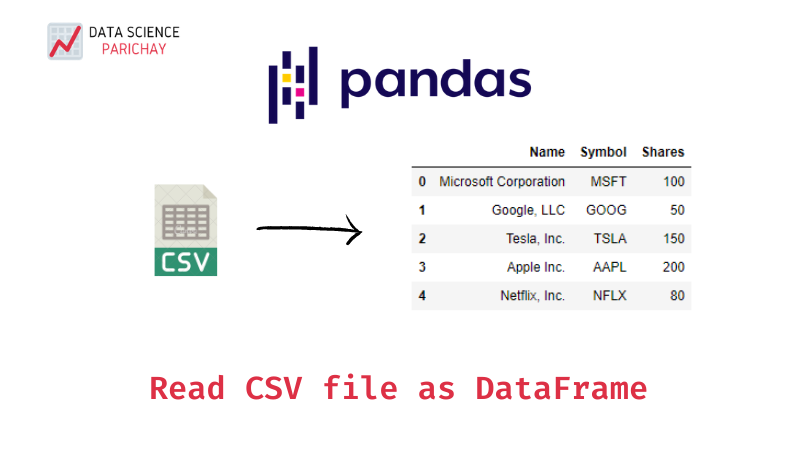